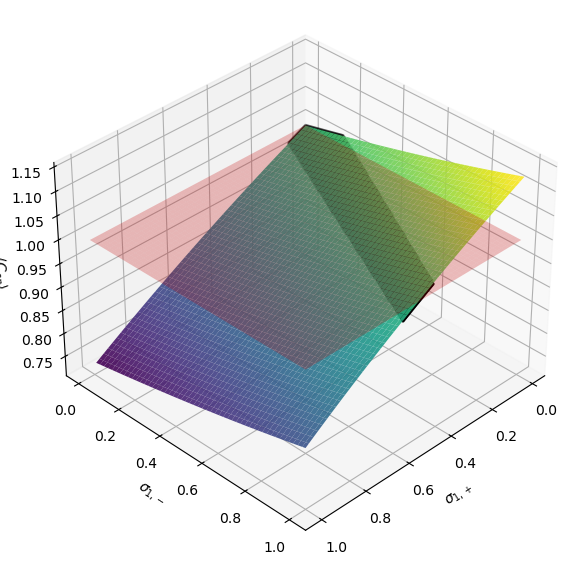

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp2f1
from mpl_toolkits.mplot3d import Axes3D

# Parámetros fijos
K_plus = 1.0
K_minus = 2.0

a = K_plus/(K_plus+ K_minus)
# Rango de sigma
sigma_plus = np.linspace(0.01, 1, 200)
sigma_minus = np.linspace(0.01, 1, 200)

S_plus, S_minus = np.meshgrid(sigma_plus, sigma_minus)


# Calcular <C_on>
def C_on(S_plus, S_minus):
    l1= (K_plus+ K_minus)
    return K_plus/l1 + ((K_plus*S_minus - K_minus*S_plus)/l1**3)*(1- (S_plus+ S_minus)/l1**2 )**(-1.5) 


Z = C_on(S_plus, S_minus)/a

# eliminar problemas numéricos
#Z = np.nan_to_num(Z)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# superficie
ax.plot_surface(S_plus, S_minus, Z,
                cmap='viridis',
                alpha=0.9)

# plano Z = 1
Z_plane = np.ones_like(Z)
ax.plot_surface(S_plus, S_minus, Z_plane,
                color='red',
                alpha=0.25)

# curva de intersección
mask = np.isclose(Z, 1, atol=0.02)

ax.scatter(S_plus[mask],
           S_minus[mask],
           Z[mask],
           color='black',
           s=3)

ax.set_xlabel(r'$\sigma_{1,+}$')
ax.set_ylabel(r'$\sigma_{1,-}$')
ax.set_zlabel(r'$\langle C_{on} \rangle$')

ax.view_init(35,45)

plt.show()

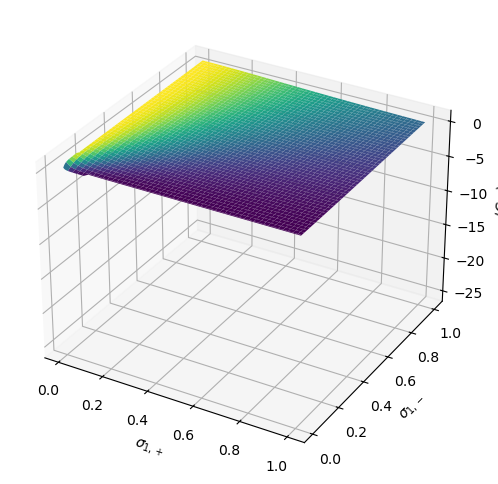

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp2f1

# Parámetros
K_plus = 1.0
K_minus = 2.0

# Rango de sigmas
sigma_plus = np.linspace(0.01, 1, 200)
sigma_minus = np.linspace(0.01, 1, 200)

S_plus, S_minus = np.meshgrid(sigma_plus, sigma_minus)

# Calcular alphas
alpha_plus = K_plus / S_plus
alpha_minus = K_minus / S_minus

# argumento de la hipergeométrica
z = 1 - (S_plus / S_minus)

def C_on(alpha_minus, alpha_plus, z):
    
    l1 = alpha_plus / (alpha_plus + alpha_minus)

    # valor general
    val = l1 * hyp2f1(1, alpha_minus, alpha_plus + alpha_minus + 1, z)

    # manejar el caso z=0
    val = np.where(np.abs(z) < 1e-12, l1, val)

    return val

# calcular superficie
Z = C_on(alpha_minus, alpha_plus, z)

# gráfica
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(S_plus, S_minus, Z, cmap='viridis')

ax.set_xlabel(r'$\sigma_{1,+}$')
ax.set_ylabel(r'$\sigma_{1,-}$')
ax.set_zlabel(r'$\langle C_{on} \rangle$')

plt.show()

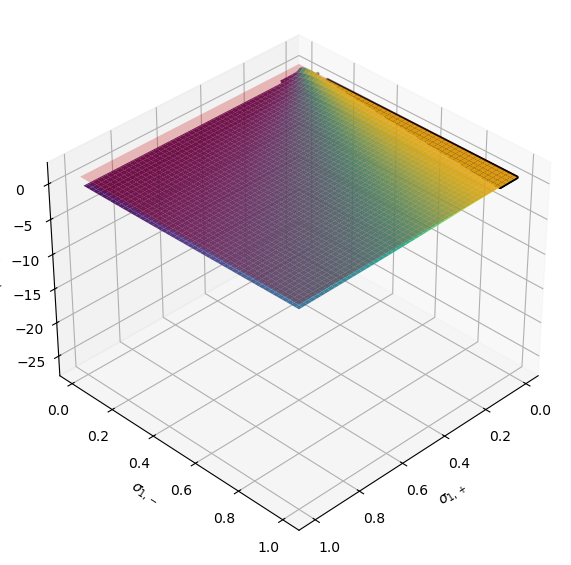

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp2f1

# Parámetros
K_plus = 1.0
K_minus = 2.0

sigma_plus = np.linspace(0.01, 1, 200)
sigma_minus = np.linspace(0.01, 1, 200)

S_plus, S_minus = np.meshgrid(sigma_plus, sigma_minus)

alpha_plus = K_plus / S_plus
alpha_minus = K_minus / S_minus

z = 1 - (S_plus / S_minus)

def C_on(alpha_minus, alpha_plus, z):

    l1 = alpha_plus/(alpha_plus + alpha_minus)

    val = l1 * hyp2f1(1, alpha_minus,
                     alpha_plus + alpha_minus + 1,
                     z)

    val = np.where(np.abs(z) < 1e-12, l1, val)

    return val

Z = C_on(alpha_minus, alpha_plus, z)

# eliminar problemas numéricos
#Z = np.nan_to_num(Z)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# superficie
ax.plot_surface(S_plus, S_minus, Z,
                cmap='viridis',
                alpha=0.9)

# plano Z = 1
Z_plane = np.ones_like(Z)
ax.plot_surface(S_plus, S_minus, Z_plane,
                color='red',
                alpha=0.25)

# curva de intersección
mask = np.isclose(Z, 1, atol=0.02)

ax.scatter(S_plus[mask],
           S_minus[mask],
           Z[mask],
           color='black',
           s=3)

ax.set_xlabel(r'$\sigma_{1,+}$')
ax.set_ylabel(r'$\sigma_{1,-}$')
ax.set_zlabel(r'$\langle C_{on} \rangle$')

ax.view_init(35,45)

plt.show()

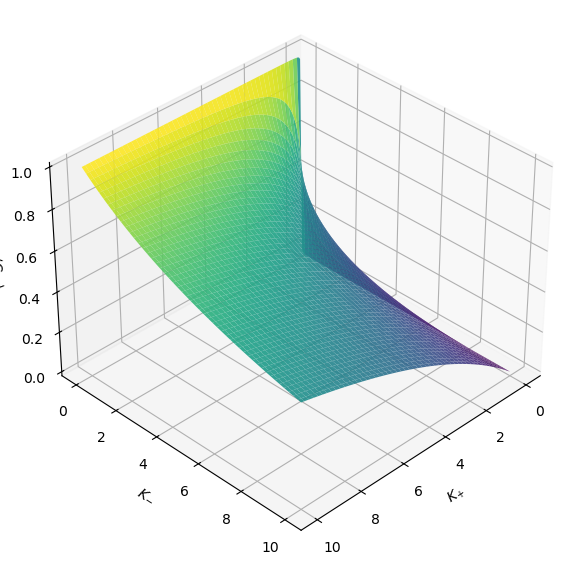

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp2f1
from mpl_toolkits.mplot3d import Axes3D


# Rango de K´s
K_plus = np.linspace(0.001, 10, 200)
K_minus = np.linspace(0.001, 10, 200)

K_plus, K_minus = np.meshgrid(K_plus, K_minus)


# Calcular <C_on>
def C_on(K_plus, K_minus):
    return K_plus/(K_plus+ K_minus)


Z = C_on(K_plus, K_minus)

# eliminar problemas numéricos
#Z = np.nan_to_num(Z)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# superficie
ax.plot_surface(K_plus, K_minus, Z,
                cmap='viridis',
                alpha=0.9)


ax.set_xlabel(r'$K_{+}$')
ax.set_ylabel(r'$K_{-}$')
ax.set_zlabel(r'$\langle C_{on} \rangle$')

ax.view_init(35,45)

plt.show()